# Clase Web scrapping

In [1]:
import lxml
import requests 
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import pandas as pd

El **web scraping** es una técnica utilizada para extraer información de páginas web. 

Para acceder a una página web desde Python, es necesario realizar una solicitud (request) al servidor.

## Librería requests

Lo más báscio para utilizar es la librería **requests**, que permite enviar solicitudes a través del protocolo HTTPS y obtener el contenido de una página. 

El comando **get()** es el que vamos a usar para traer la información de una página. Cada vez que ejecutamos el comando get estamos enviando una consulta al servidor. Hay que ser responsables en el uso de las consultas ya que si se ejecutan demasiadas pueden generar problemas en el servidor o incluso pueden bloquear nuestra IP por uso indebido.


Primero, usamos requests.get para hacer la consulta

In [2]:
a = requests.get("https://www.pagina12.com.ar/")

No tuvimos error, pero eso no significa mucho por ahora. Vamos a chequear el **status** de nuestro request. Vamos a ver que nos va a devolver un misterioso número

In [3]:
a.status_code

200

Acá podemos chequear las distintas posibilidades de status. Nos tocó 200 así que funcionó!  

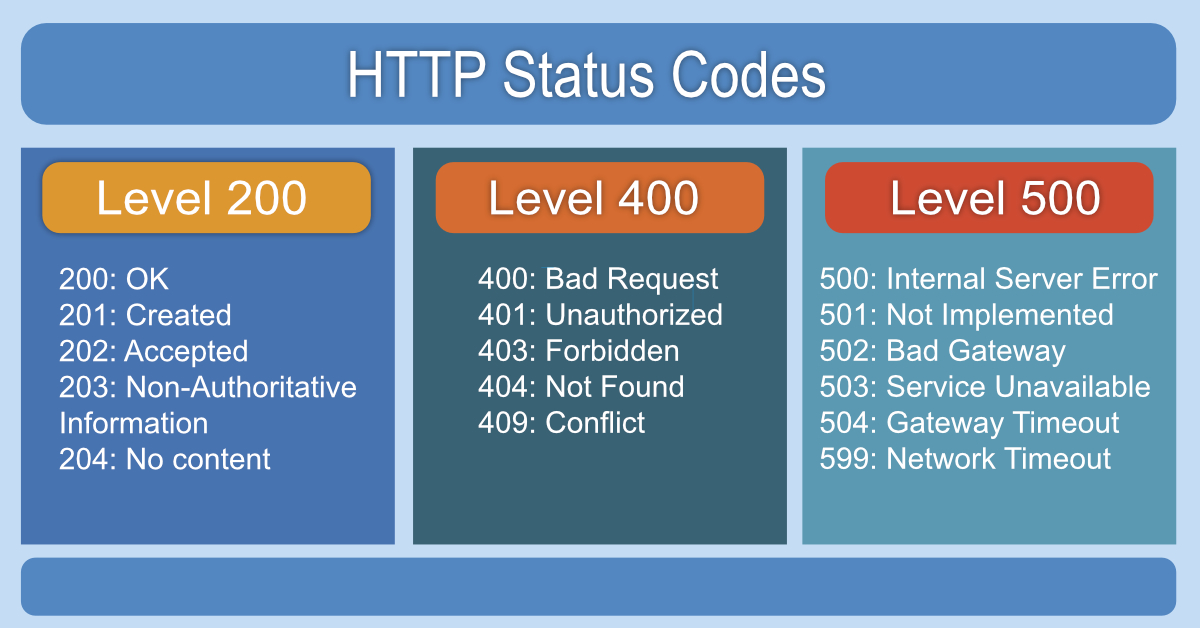

Con **content** podemos ver que hay adentro de nuestro request

In [4]:
a.content

b'<!DOCTYPE html><html lang="es" dir="ltr"><head><meta name="viewport" content="width=device-width, initial-scale=1"/><link rel="icon" href="/pf/resources/favicon-v3.ico?d=103&amp;mxId=00000000"/><link rel="apple-touch-icon" sizes="180x180" href="/pf/resources/favicon/180X180.png?d=103&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="32x32" href="/pf/resources/favicon/32X32.png?d=103&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="16x16" href="/pf/resources/favicon/16X16.png?d=103&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="192x192" href="/pf/resources/favicon/192X192.png?d=103&amp;mxId=00000000"/><title>P\xc3\xa1gina | 12: La otra mirada sobre Argentina y el mundo</title><meta property="og:title" content="P\xc3\xa1gina|12"/><meta name="twitter:title" content="P\xc3\xa1gina|12"/><meta property="og:image" content="https://www.pagina12.com.ar/resizer/v2/https%3A%2F%2Fwww.pagina12.com.ar%2Fresources%2Fp12logo.svg?auth=811d0fc63a912d1f8dc56b650f3a0

Hay algunas herramientas como BeautifulSoup o Selenium que permiten explorar paginas web con mucha fluidez. Pueden chusmear el curso de Gustavo Juantorena para explorar más https://www.youtube.com/watch?v=yKi9-BfbfzQ&ab_channel=freeCodeCampEspa%C3%B1ol. También en este repo hay una versión más larga de este notebook: https://github.com/FedeGiovannetti/Clase_webscraping

## Uso de APIs

Una API (Application Programming Interface) define una sintaxis estandarízada que permite la comunicación entre nosotros (clientes) y un determinado servidor.

Generalmente, cada API tiene sus instrucciones que describen la forma de comunicarnos con sus **endpoints** para extraer la información requerida a partir de una URL

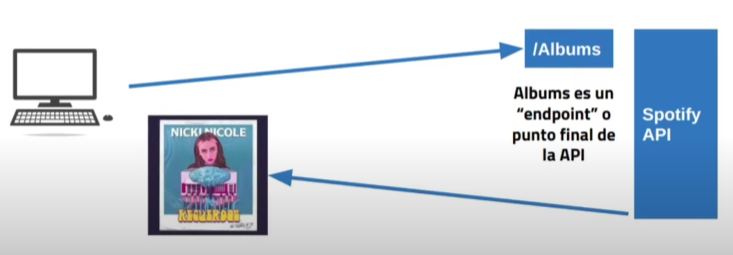
Figura extraida del curso de Gustavo Juantorena https://www.youtube.com/watch?v=yKi9-BfbfzQ&ab_channel=freeCodeCampEspa%C3%B1ol Mirenlo!

Usualmente, la respuesta de una API llega en formato *JSON*, que es un formato bastante distinto a los csv que venimos manejando.

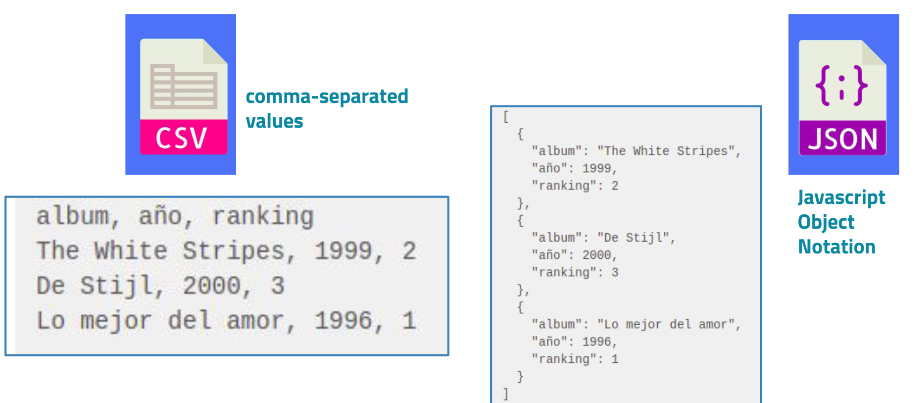
Fuente: https://www.youtube.com/watch?v=yKi9-BfbfzQ&ab_channel=freeCodeCampEspa%C3%B1ol 

## API Transporte BA - ECO BICIS

El gobierno de la Ciudad de Buenos Aires tiene una API mas o menos piola para levantar datos sobre colectivos, subtes, trenes y bicis en el ámbito de la Ciudad https://api-transporte.buenosaires.gob.ar/

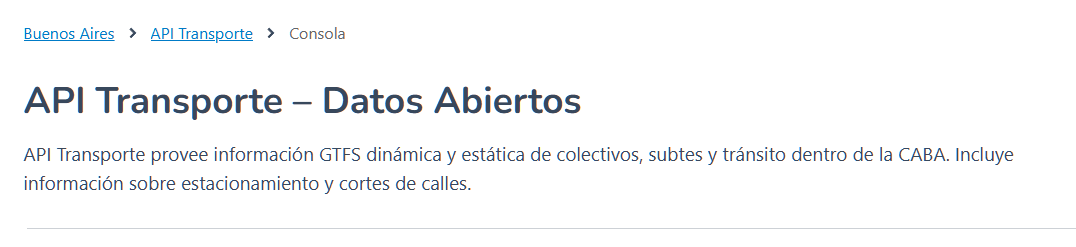

Para poder acceder a este tipo de APIs, es común tener que registrarse para obtener algún tipo de credencial. Se pueden registrar acá: https://api-transporte.buenosaires.gob.ar/registro

Ahora si, vamos a probar descargar la información sobre las estaciones de eco bici de Buenos Aires

In [6]:
link_api='https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationInformation?'
response = requests.get(link_api)
response.status_code


401

Estamos desautorizados (?) porque no pusimos las credenciales. Para hacerlo, tenemos que incluir las mismas dentro del parámetro **params**

In [8]:
# Por motivos de seguridad, las credenciales
# no estan incluidas aquí.
credenciales = {
    "client_id": "f3429f52737b4e019607007f7454602f",
    "client_secret": "E09120C8BC17468fBd98Bd7F37173674"
}

response = requests.get(link_api, params=credenciales)
response.status_code

200

Para poder abrirlo, vamos a tener que usar **json()** y veremos la estructura de los datos.

In [9]:
estaciones_info = response.json()
estaciones_info

{'last_updated': 1779308170,
 'ttl': 11,
 'data': {'stations': [{'station_id': '2',
    'external_id': '7dbf224d-df81-11ef-9840-060733a00d35',
    'name': '002 - Retiro I',
    'physical_configuration': 'SMARTLITMAPFRAME',
    'lat': -34.59242413,
    'lon': -58.37470988999999,
    'altitude': None,
    'address': 'AV. Dr. José María Ramos Mejía 1300',
    'post_code': '11111',
    'capacity': 40,
    'is_charging_station': False,
    'rental_methods': ['key', 'transitcard', 'phone'],
    'groups': ['RETIRO'],
    'obcn': '',
    'short_name': '',
    'nearby_distance': 1000.0,
    '_ride_code_support': True,
    'rental_uris': {}},
   {'station_id': '3',
    'external_id': '7dbf2536-df81-11ef-9840-060733a00d35',
    'name': '003 - ADUANA',
    'physical_configuration': 'SMARTLITMAPFRAME',
    'lat': -34.61220714255728,
    'lon': -58.369129063788996,
    'altitude': None,
    'address': 'Av. Paseo Colón 380',
    'cross_street': '.',
    'post_code': 'C1063',
    'capacity': 28,
    '

Exploremos un poco los distintos **niveles** que tiene este JSON. Bajo el nombre "data" estan todos los datos y en stations" vamos a finalmente encontrar algo parecido a un dataframe. 

Estas vueltas suelen ser algo típico de cualquier scrapeo.

## Vamos a trabajar con algunas preguntas concretas:
1. ¿Cuál es el barrio con más estaciones?
2. ¿Cuál es el barrio con más capacidad?
3. ¿Hay una relación entre la cantidad de estaciones y la capacidad?

## Vamos a analizar la información actual (tiempo real) de las estaciones

Algo lindo sería analizar si hay estaciones o barrios que les vendría bien tener más bicis. Para eso, vamos a tener que ir al endpoint https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationStatus?


In [276]:

link_api='https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationStatus?'


response = requests.get(link_api, params= credenciales)
estaciones_estado = response.json()
estaciones_estado
 

{'last_updated': 1770682434,
 'ttl': 10,
 'data': {'stations': [{'station_id': '2',
    'num_bikes_available': 5,
    'num_bikes_available_types': {'mechanical': 5, 'ebike': 0},
    'num_bikes_disabled': 1,
    'num_docks_available': 34,
    'num_docks_disabled': 0,
    'last_reported': 1770682278,
    'is_charging_station': False,
    'status': 'IN_SERVICE',
    'is_installed': 1,
    'is_renting': 1,
    'is_returning': 1,
    'traffic': None},
   {'station_id': '3',
    'num_bikes_available': 0,
    'num_bikes_available_types': {'mechanical': 0, 'ebike': 0},
    'num_bikes_disabled': 0,
    'num_docks_available': 28,
    'num_docks_disabled': 0,
    'last_reported': 1770682278,
    'is_charging_station': False,
    'status': 'IN_SERVICE',
    'is_installed': 1,
    'is_renting': 1,
    'is_returning': 1,
    'traffic': None},
   {'station_id': '4',
    'num_bikes_available': 0,
    'num_bikes_available_types': {'mechanical': 0, 'ebike': 0},
    'num_bikes_disabled': 0,
    'num_dock

Vamos a responder las siguientes preguntas:
1. ¿Cómo calcularías la disponibilidad de bicis de una estación? Es decir, ¿Cuán usada es una estación?
2. ¿Las estaciones con más capacidad son las más usadas?
3. ¿Cómo podríamos identificar barrios con estaciones que sean poco usadas?